In [1]:
!pip install spacy -q
!python -m spacy download en_core_web_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 58.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import os
os._exit(0)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import pandas as pd
import numpy as np
import re
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm", disable=["ner"])  # NER is slow, not needed yet

In [ ]:
df = pd.read_csv("AI_Human.csv")

print(df.shape)
print(df.head())
print(df['generated'].value_counts())  # check label balance
print(df.isnull().sum())               # check for nulls

(487235, 2)
                                                text  generated
0  Cars. Cars have been around since they became ...        0.0
1  Transportation is a large necessity in most co...        0.0
2  "America's love affair with it's vehicles seem...        0.0
3  How often do you ride in a car? Do you drive a...        0.0
4  Cars are a wonderful thing. They are perhaps o...        0.0
generated
0.0    305797
1.0    181438
Name: count, dtype: int64
text         0
generated    0
dtype: int64


In [ ]:
df = pd.read_pickle("preprocessed.pkl")

In [ ]:
print(len(df), len(feature_df))

486700 486700


In [ ]:
print('sentences' in df.columns)

True


In [ ]:
print(device)

cuda


In [4]:
print("\nFeature list:")
for i, col in enumerate([c for c in feature_df.columns if c != "label"], 1):
    print(f"{i:02d}. {col}")


Feature list:
01. sent_len_mean
02. sent_len_std
03. sent_len_min
04. sent_len_max
05. sent_len_range
06. burstiness
07. sent_len_cv
08. ttr
09. root_ttr
10. corrected_ttr
11. msttr
12. hapax_ratio
13. rare_ratio
14. top10_coverage
15. top1_word_freq
16. vocab_size
17. discourse_marker_rate
18. safe_vocab_rate
19. importance_word_rate
20. template_phrase_count
21. it_is_rate
22. this_is_rate
23. there_is_rate
24. sentence_start_marker_rate
25. synonym_cycle_score
26. safe_vocab_diversity
27. intro_template_flag
28. ending_template_flag
29. stacked_marker_count
30. marker_burstiness
31. word_entropy
32. normalized_word_entropy
33. bigram_entropy
34. normalized_bigram_entropy
35. trigram_entropy
36. normalized_trigram_entropy
37. bigram_reuse_rate
38. trigram_reuse_rate
39. fourgram_reuse_rate
40. word_redundancy
41. long_phrase_redundancy
42. local_entropy_mean
43. local_entropy_std
44. local_entropy_min
45. local_entropy_max
46. entropy_variation_ratio
47. zipf_deviation
48. zipf_slop

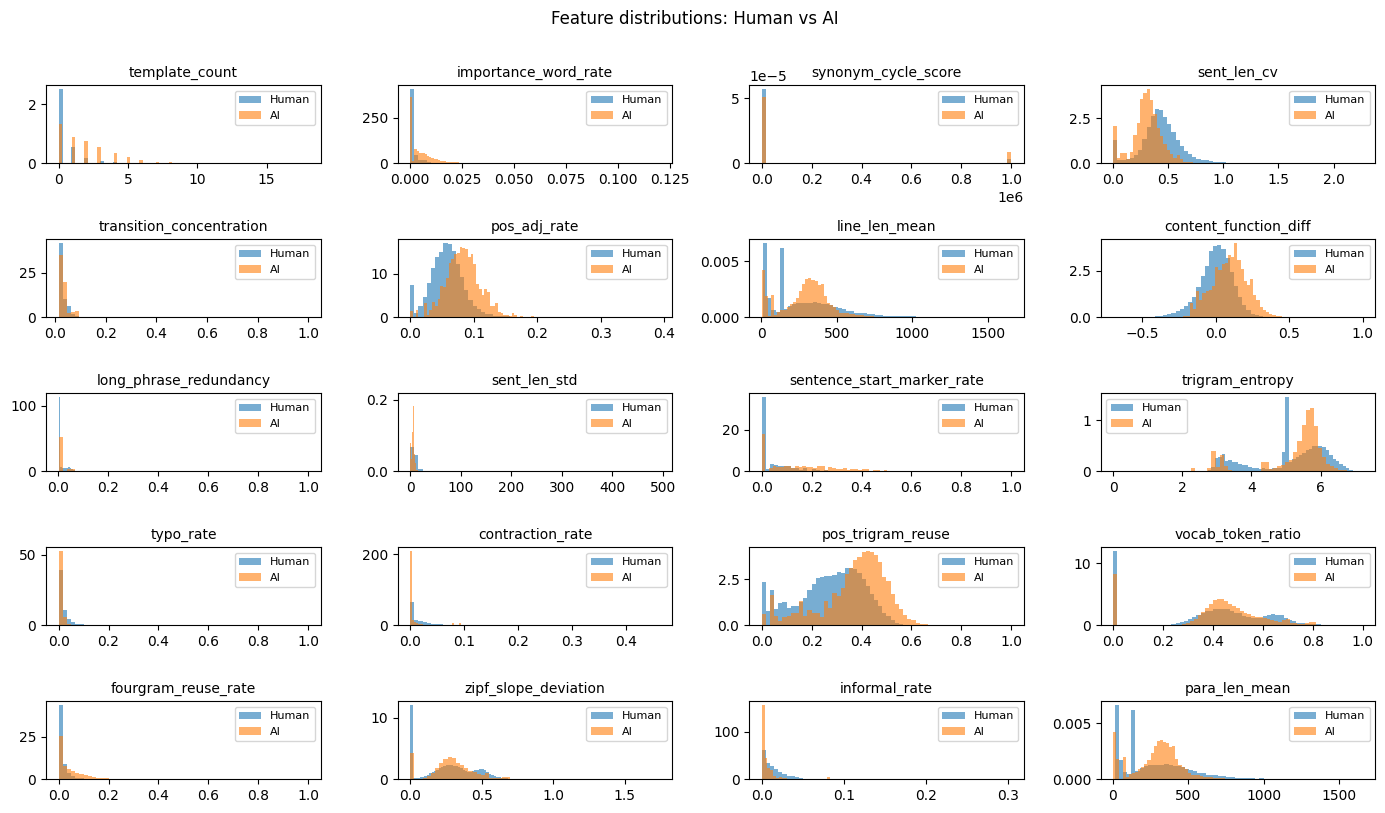

In [5]:
import matplotlib.pyplot as plt

key = [
    "template_count",
    "importance_word_rate",
    "synonym_cycle_score",
    "sent_len_cv",
    "transition_concentration",
    "pos_adj_rate",
    "line_len_mean",
    "content_function_diff",
    "long_phrase_redundancy",
    "sent_len_std",
    "sentence_start_marker_rate",
    "trigram_entropy",
    "typo_rate",
    "contraction_rate",
    "pos_trigram_reuse",
    "vocab_token_ratio",
    "fourgram_reuse_rate",
    "zipf_slope_deviation",
    "informal_rate",
    "para_len_mean"
]

fig, axes = plt.subplots(5, 4, figsize=(14, 8))

for ax, feat in zip(axes.flatten(), key):
    human = feature_df[feature_df["label"] == 0.0][feat].dropna()
    ai = feature_df[feature_df["label"] == 1.0][feat].dropna()

    ax.hist(human, bins=60, alpha=0.6, density=True, label="Human")
    ax.hist(ai, bins=60, alpha=0.6, density=True, label="AI")

    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Feature distributions: Human vs AI", y=1.01)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

In [6]:
print("\nMean values per class:")
print(
    feature_df.groupby("label")[key]
    .mean()
    .T
    .rename(columns={0.0: "Human", 1.0: "AI"})
)


Mean values per class:
label                              Human             AI
template_count                  0.373218       1.813356
importance_word_rate            0.001178       0.005388
synonym_cycle_score         47411.690266  149063.890740
sent_len_cv                     0.428279       0.306522
transition_concentration        0.031130       0.034682
pos_adj_rate                    0.057559       0.083285
line_len_mean                 278.018815     294.681397
content_function_diff           0.002550       0.093133
long_phrase_redundancy          0.011745       0.010795
sent_len_std                    8.419078       5.664515
sentence_start_marker_rate      0.047620       0.156629
trigram_entropy                 5.110359       5.242369
typo_rate                       0.017345       0.008146
contraction_rate                0.024255       0.011524
pos_trigram_reuse               0.273763       0.371316
vocab_token_ratio               0.400107       0.421361
fourgram_reuse_rate     

In [7]:
print(feature_df.shape)
print(feature_df.isnull().sum().sum())
print(feature_df["label"].value_counts())

(464943, 116)
0
label
0.0    249854
1.0    215089
Name: count, dtype: int64


In [8]:
print("Columns:", len(feature_df.columns))
print("Nulls:", feature_df.isnull().sum().sum())
print(feature_df["label"].value_counts())

Columns: 116
Nulls: 0
label
0.0    249854
1.0    215089
Name: count, dtype: int64


In [9]:
print(feature_df.columns)

Index(['sent_len_mean', 'sent_len_std', 'sent_len_min', 'sent_len_max',
       'sent_len_range', 'burstiness', 'sent_len_cv', 'ttr', 'root_ttr',
       'corrected_ttr',
       ...
       'header_count', 'intro_outro_balance', 'sbert_adj_sim_mean',
       'sbert_adj_sim_std', 'sbert_adj_sim_max', 'sbert_global_sim_mean',
       'sbert_sim_variance', 'sbert_coherence_drop', 'label', 'text_clean'],
      dtype='object', length=116)


In [10]:
from sklearn.model_selection import train_test_split

X = feature_df.drop(columns=["label", "text_clean"])
y = feature_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(371954, 114)
(92989, 114)


In [11]:
!pip install xgboost

In [14]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

# Convert DataFrames to NumPy arrays to ensure compatibility
model.fit(X_train.values, y_train.values)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

pred = model.predict(X_test.values)
proba = model.predict_proba(X_test.values)[:, 1]

print(classification_report(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))

In [16]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(20))

template_count                0.185473
importance_word_rate          0.072367
synonym_cycle_score           0.047840
sent_len_cv                   0.040598
transition_concentration      0.032689
pos_adj_rate                  0.031608
line_len_mean                 0.025765
content_function_diff         0.024666
long_phrase_redundancy        0.022559
sent_len_std                  0.022128
sentence_start_marker_rate    0.018722
trigram_entropy               0.016552
typo_rate                     0.016039
contraction_rate              0.015504
pos_trigram_reuse             0.014099
vocab_token_ratio             0.014097
fourgram_reuse_rate           0.014075
zipf_slope_deviation          0.013136
informal_rate                 0.012648
para_len_mean                 0.012644
dtype: float32


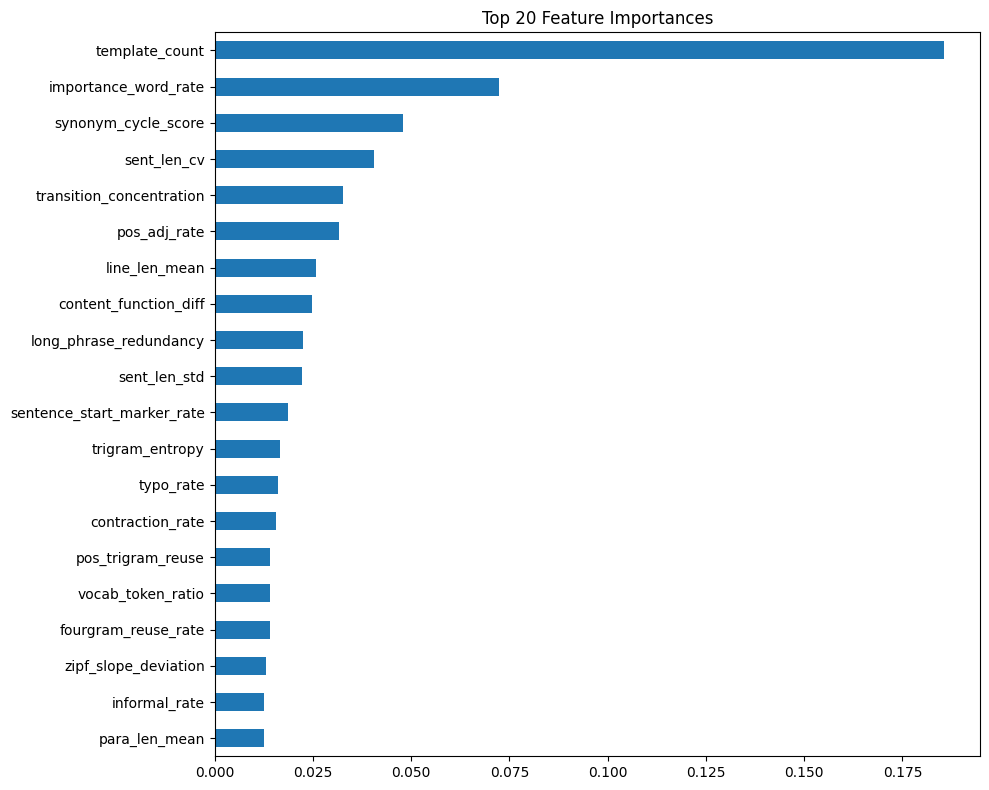

In [17]:
import matplotlib.pyplot as plt

importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [14]:
import pickle

# save trained model
with open("final_xgb_ai_detector.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully as xgb_ai_detector.pkl")

Model saved successfully as xgb_ai_detector.pkl


In [ ]:
import os

print(os.path.exists("xgb_ai_detector.pkl"))
print(os.path.getsize("xgb_ai_detector.pkl") / 1024 / 1024, "MB")

True
3.3300609588623047 MB


In [15]:
feature_columns = X_train.columns.tolist()

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("Feature columns saved.")
print("Total columns:", len(feature_columns))

Feature columns saved.
Total columns: 114


In [ ]:
with open("xgb_ai_detector.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Loaded successfully.")
print(type(loaded_model))

Loaded successfully.
<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
text = input("Enter text: ")
predict_text(text)

Enter text:  Lo, the grievous strife betwixt Russia and Ukraine standeth as one of the most sorrowful and momentous wars of this age. In the year of our Lord two thousand and twenty-two, the realm of Russia did launch a mighty invasion upon the lands of Ukraine, thereby kindling a fire of conflict whose embers had long smouldered since the taking of Crimea in years past. Since that dire hour, many a city hath been laid to ruin, fair homes reduced to dust, and countless innocents made to suffer death, wound, and exile. The lamentations of the people rise as unto heaven, for multitudes have been driven from their native soil, seeking shelter in foreign lands. Nor hath this tempest touched those realms alone, for the whole world hath felt its tremor: the flow of grain and fuel hath been sorely hindered, trade disturbed, and nations cast into uncertainty and want. Great powers beyond the field of battle have taken sides, some lending aid and succour unto Ukraine, whilst others lay heavy sa


Prediction: Human-written
AI probability: 0.3421
Human probability: 0.6579


In [ ]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================
# LOAD FEATURE MATRIX
# =========================
feature_df = pd.read_pickle("features_final.pkl")

print("Feature DF shape:", feature_df.shape)
print("Null count:", feature_df.isnull().sum().sum())
print(feature_df["label"].value_counts())

# =========================
# LOAD TRAINED MODEL
# =========================
with open("xgb_ai_detector.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully.")

Feature DF shape: (486700, 62)
Null count: 0
label
0.0    305368
1.0    181332
Name: count, dtype: int64
Model loaded successfully.


In [ ]:
X = feature_df.drop(columns=["label"])
y = feature_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (389360, 61)
Test shape: (97340, 61)


In [11]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))

ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("Baseline Confusion Matrix")
plt.show()

NameError: name 'model' is not defined